In [1]:
%load_ext autoreload
%autoreload 2
import os
import copy
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from utils import *
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import flwr as fl

In [2]:
CLIENT_ID = 3

In [3]:
NUM_CLIENTS = 4
SERVER_ADDRESS = "10.64.240.57:8080"

DEVICE = "mps"
BATCH_SIZE = 4
LOCAL_EPOCHS = 1
LR = 1e-4

print("Using device:", DEVICE)

Using device: mps


In [4]:
RESIZE_TO = (448,448)

In [5]:
#Dataset from UWF4DR
# uf_train_dir = "/Users/pritam/Desktop/Mtech Project/RDR Training/1. Images"
uf_val_dir = "/Users/pritam/Desktop/Mtech Project/RDR Training/RDR Validation/1. Images/2. Validation"
# training_images_uf = []
validation_images_uf = []
# for i in range(1, 202):
#     img_path = os.path.join(uf_train_dir, f"uwf4dr_rdr_dme_train_{i}.jpg")
#     if os.path.exists(img_path):
#         img = Image.open(img_path).convert('RGB')
#         img = img.resize(RESIZE_TO)
#         img_array = np.array(img, dtype=np.float32) / 255.0
#         training_images_uf.append(img_array)
for i in range(1, 51):
    img_path = os.path.join(uf_val_dir, f"uwf4dr_rdr_dme_val_{i}.jpg")
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        img = img.resize(RESIZE_TO)
        img_array = np.array(img, dtype=np.float32) / 255.0
        validation_images_uf.append(img_array)
# training_images_uf = np.array(training_images_uf)
# print(f"UWF4DR Training images shape: {training_images_uf.shape}")
validation_images_uf = np.array(validation_images_uf)
print(f"UWF4DR Validation images shape: {validation_images_uf.shape}")


UWF4DR Validation images shape: (50, 448, 448, 3)


In [6]:
validation_labels_uf = pd.read_csv("/Users/pritam/Desktop/Mtech Project/RDR Training/RDR Validation/2. Groundtruths/2. Validation.csv")
y_test = np.array(validation_labels_uf["referable diabetic retinopathy"])
np.unique(y_test, return_counts=True)

(array([0, 1]), array([21, 29]))

In [7]:
import random
import torch
import torchvision.transforms.v2 as transforms # Using v2 namespace
import torchvision.transforms.v2.functional as TF

class DRTransform:
    def __call__(self, img):
        # 1. Resize and apply custom geometric/color filters
        img = img.resize((512, 512))
        img = apply_elliptical_mask(img)
        img = residual_gaussian_blur(img, p=0.5)
        img = apply_clahe(img, p=0.5)

        # 2. Random Flipping
        if random.random() < 0.5:
            img = TF.hflip(img)

        # 3. Random Rotation
        if random.random() < (1/3):
            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle)

        # 4. Crop
        img = TF.center_crop(img, [448, 448])

        # 5. Convert & Normalize using v2 (ToImage + ToDtype scales to [0,1])
        img = TF.to_image(img)
        img = TF.to_dtype(img, dtype=torch.float32, scale=True)
        img = TF.normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        return img

# Aligned validation transforms using v2
val_transforms = transforms.Compose([
    transforms.Resize((512, 512)), # Added to mirror training dimensions
    transforms.CenterCrop(448),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_transform = DRTransform()


In [8]:
class DRDataset(torch.utils.data.Dataset): 
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        image = Image.fromarray((image * 255).astype(np.uint8)) # Convert back to PIL Image
        
        if self.transform:
            image = self.transform(image) # Apply transformations
        
        return image, label

In [9]:
BATCH_SIZE = 4

In [10]:
X_train = np.load("X_train_combined.npy")
y_train = np.load("y_train_combined.npy")

print(X_train.shape)
print(y_train.shape)

(401, 512, 512, 3)
(401,)


In [11]:
from sklearn.model_selection import train_test_split

# Explicitly use test_size=0.2 instead of just 0.2
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train, 
    y_train, 
    test_size=0.2,          # Fixed positional argument bug
    random_state=21, 
    shuffle=True, 
    stratify=y_train
)

print(f"Shape of training data is {X_train_final.shape}")
print(f"Shape of training label is {y_train_final.shape}")
print(f"Shape of validation data is {X_val_final.shape}")
print(f"Shape of validation label is {y_val_final.shape}")

Shape of training data is (320, 512, 512, 3)
Shape of training label is (320,)
Shape of validation data is (81, 512, 512, 3)
Shape of validation label is (81,)


In [12]:
def split_data_by_client(X, y, num_clients, client_id, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(X))
    rng.shuffle(indices)

    client_indices = np.array_split(indices, num_clients)[client_id]

    return X[client_indices], y[client_indices]

X_client, y_client = split_data_by_client(
    X_train_final,
    y_train_final,
    NUM_CLIENTS,
    CLIENT_ID
)

print("Client ID:", CLIENT_ID)
print("Client data:", X_client.shape, y_client.shape)
print("Label distribution:", np.unique(y_client, return_counts=True))

Client ID: 3
Client data: (80, 512, 512, 3) (80,)
Label distribution: (array([0, 1]), array([37, 43]))


In [13]:
# y_test_tensors = torch.tensor(y_test, dtype=torch.long)

In [14]:
from torchvision.transforms.v2 import functional as TF
class DRDataset(torch.utils.data.Dataset): 
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        # image = Image.fromarray((image * 255).astype(np.uint8)) # Convert back to PIL Image
        image = TF.to_pil_image((image * 255).to(torch.uint8))
        if self.transform:
            image = self.transform(image) # Apply transformations
        
        return image, label

In [15]:
def create_dataloader(X, y, train=False, batch_size=4):

    # Convert images
    if not torch.is_tensor(X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
    else:
        X_tensor = X.float()

    # NHWC -> NCHW
    X_tensor = X_tensor.permute(0, 3, 1, 2)

    # Convert labels
    if not torch.is_tensor(y):
        y_tensor = torch.tensor(y, dtype=torch.float32)
    else:
        y_tensor = y.float()

    if train:
        dataset = DRDataset(
            X_tensor,
            y_tensor,
            transform=train_transform
        )
    else:
        dataset = DRDataset(
            X_tensor,
            y_tensor,
            transform=val_transforms
        )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=train,
        num_workers=0
    )

    return loader

In [16]:
train_loader = create_dataloader(
    X_client,
    y_client,
    train=True
)

val_loader = create_dataloader(
    X_val_final,
    y_val_final,
    train=False
)
test_loader = create_dataloader(validation_images_uf, y_test,train=False)

In [17]:
def get_model():
    model = efficientnet_b0(weights="IMAGENET1K_V1")
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    return model

model = get_model().to(DEVICE)

In [18]:
def get_parameters(model):
    return [
        val.cpu().numpy()
        for _, val in model.state_dict().items()
    ]


def set_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)

    state_dict = {
        k: torch.tensor(v)
        for k, v in params_dict
    }

    model.load_state_dict(state_dict, strict=True)

In [19]:
def train_one_client(model, train_loader, epochs, lr, device):
    model.train()

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for epoch in range(epochs):
        for images, labels in train_loader:

            images = images.to(device)

            # IMPORTANT FIX
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples

    return avg_loss, acc

In [20]:
def evaluate_model(model, val_loader, device):
    model.eval()
    criterion = nn.BCEWithLogitsLoss()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples
    

In [21]:
class DRFlowerClient(fl.client.NumPyClient):
    def get_parameters(self, config):
        return get_parameters(model)

    def fit(self, parameters, config):
        set_parameters(model, parameters)

        loss, acc = train_one_client(
            model=model,
            train_loader=train_loader,
            epochs=LOCAL_EPOCHS,
            lr=LR,
            device=DEVICE
        )

        print(f"Client {CLIENT_ID} | train loss: {loss:.4f} | train acc: {acc:.4f}")

        return get_parameters(model), len(X_client), {
            "loss": float(loss),
            "accuracy": float(acc),
            "client_id": CLIENT_ID,
        }

    def evaluate(self, parameters, config):
        set_parameters(model, parameters)

        loss, acc = evaluate_model(
            model=model,
            val_loader=val_loader,
            device=DEVICE
        )

        print(f"Client {CLIENT_ID} | val loss: {loss:.4f} | val acc: {acc:.4f}")

        return loss, len(val_loader.dataset), {
            "accuracy": float(acc),
            "client_id": CLIENT_ID,
        }

In [22]:
GRPC_MAX_MESSAGE_LENGTH = 1024 * 1024 * 1024

fl.client.start_numpy_client(
    server_address="127.0.0.1:8080",
    client=DRFlowerClient().to_client(),
    grpc_max_message_length=GRPC_MAX_MESSAGE_LENGTH,
    insecure=True,
)

	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      
INFO :      [RUN 0, ROUND ]
INFO :      Received: train message 6877642f-ab39-45ce-bba6-4e776e31c725
INFO :      Sent reply


Client 3 | train loss: 0.6384 | train acc: 0.6750


INFO :      
INFO :      [RUN 0, ROUND ]
INFO :      Received: evaluate message 2a510d0d-fb8c-4c03-b0ef-0f89654aa3cd
INFO :      Sent reply


Client 3 | val loss: 0.6108 | val acc: 0.7284


INFO :      
INFO :      [RUN 0, ROUND ]
INFO :      Received: train message ebfce109-1f93-4c8e-920f-2a3e202785d2
INFO :      Sent reply


...

Client 3 | val loss: 0.3971 | val acc: 0.8889


INFO :      
INFO :      [RUN 0, ROUND ]
INFO :      Received: train message 5151d546-7cce-4fb3-9d23-1451b82e2b4c
INFO :      Sent reply


Client 3 | train loss: 0.0803 | train acc: 0.9875


INFO :      
INFO :      [RUN 0, ROUND ]
INFO :      Received: evaluate message fdaff14d-0552-4db8-8bb9-a6222c48663c
INFO :      Sent reply
INFO :      
INFO :      [RUN 0, ROUND ]
INFO :      Received: reconnect message bfb9cc65-d444-429e-ad1d-d7fda58697ee
INFO :      Disconnect and shut down


Client 3 | val loss: 0.3668 | val acc: 0.8889


In [23]:

best_auroc = float('-inf')
best_round = None
best_path = ""

for i in range(1, 11):
    path = f"/Users/pritam/Desktop/MTech Project/federated_checkpoints/global_model_round_{i}.pth"
    print(f"Evaluating: {path}")
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    metrics = getMetricsAtThreshold(model, val_loader, DEVICE)
    if metrics["auroc"] >= best_auroc:
        best_auroc = metrics["auroc"]
        best_round = i
        best_path = path

print("\n" + "="*40)
print(f"🏆 Best Model Found at Round {best_round} with AUROC: {best_auroc:.4f}")
print(f"Loading best weights from: {best_path}")
print("="*40 + "\n")

# Fix 2: Load from 'best_path', not 'path'
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

# Final verification
print("Final Verified Metrics for Best Model:")
print(getMetricsAtThreshold(model, val_loader, DEVICE))

Evaluating: /Users/pritam/Desktop/MTech Project/federated_checkpoints/global_model_round_1.pth


FileNotFoundError: [Errno 2] No such file or directory: '/Users/pritam/Desktop/MTech Project/federated_checkpoints/global_model_round_1.pth'


Metrics at Threshold = 0.200
AUROC       : 0.9869
AUPRC       : 0.9895
Accuracy    : 0.9800
Precision   : 0.9667
Recall      : 1.0000
Specificity : 0.9524
F1 Score    : 0.9831

Confusion Matrix:
[[20  1]
 [ 0 29]]


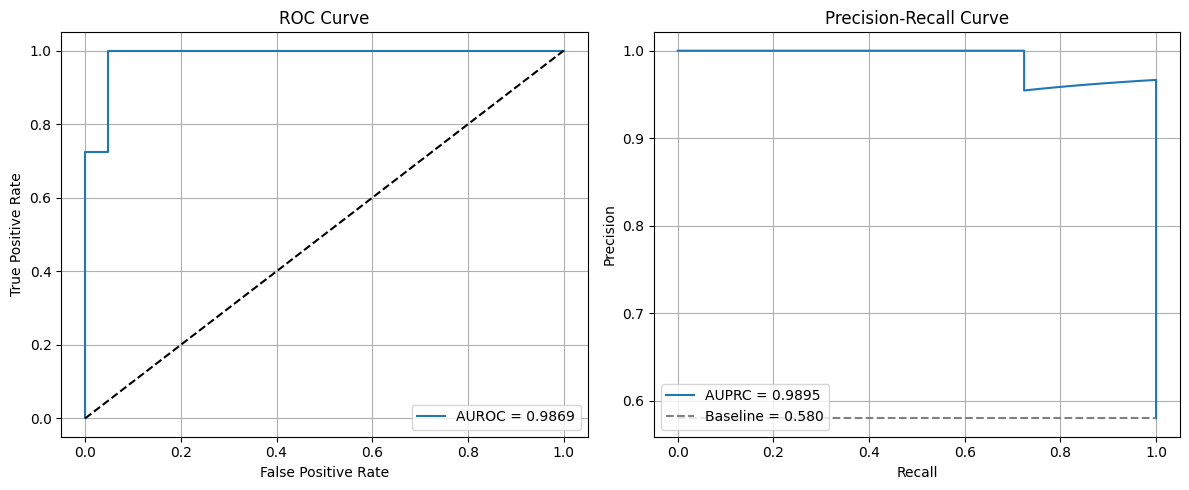

{'threshold': 0.2,
 'auroc': 0.9868637110016419,
 'auprc': 0.989511245492996,
 'accuracy': 0.98,
 'precision': 0.9666666666666667,
 'recall': 1.0,
 'specificity': 0.9523809523809523,
 'f1_score': 0.9830508474576272}

In [ ]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
getMetricsAtThreshold(model, val_loader, DEVICE, 0.2)